In [1]:
import torch
import torch.nn as nn
from practice.vit_data_downloader import get_cifar10_dataloaders

device = "cuda"
train_loader, test_loader = get_cifar10_dataloaders()

In [ ]:
from practice.inhu_vit import InhuVit
from torch.optim import Adam, Optimizer
from torch.nn.functional import cross_entropy
from torch.utils.data import DataLoader
from torch import Tensor

model = InhuVit()
optimizer = Adam(model.parameters(), lr = 0.001)
loss_fn = cross_entropy

model.to(device)

def train(model:nn.Module, optimizer:Optimizer, loss_fn, train_loader:DataLoader, test_loader:DataLoader, epoch_num:int = 10):
    train_avgloss_history:list[float] = []
    test_avgloss_history:list[float] = []
    
    for epoch_idx in range(epoch_num):
        epoch_train_loss:float = 0
        epoch_test_loss:float = 0
        
        for X,y in train_loader:
            model.train()
            X:Tensor = X.to(device)
            y:Tensor = y.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X)
            train_loss = loss_fn(y_pred, y)
            train_loss.backward()
            optimizer.step()
            
            epoch_train_loss += train_loss.item() * X.size(0)
        
        with torch.no_grad():
            model.eval()
            for X,y in test_loader:
                X:Tensor = X.to(device)
                y:Tensor = y.to(device)
                
                y_pred = model(X)
                test_loss = loss_fn(y_pred, y)
                epoch_test_loss += test_loss.item() * X.size(0)
            
        train_avgloss_history.append(epoch_train_loss / len(train_loader.dataset))
        test_avgloss_history.append(epoch_test_loss / len(test_loader.dataset))
        print(f"Epoch {epoch_idx + 1}: train loss = {train_avgloss_history[epoch_idx]:.4f}, test loss = {test_avgloss_history[epoch_idx]:.4f}")
    
    return train_avgloss_history, test_avgloss_history

In [10]:
model.zero_grad()
train_loss, test_loss = train(model, optimizer, loss_fn, train_loader, test_loader)

Epoch 1: train loss = 1.7682, test loss = 1.5592
Epoch 2: train loss = 1.4610, test loss = 1.3178
Epoch 3: train loss = 1.3468, test loss = 1.2961
Epoch 4: train loss = 1.2802, test loss = 1.2091
Epoch 5: train loss = 1.2295, test loss = 1.1832
Epoch 6: train loss = 1.1897, test loss = 1.1100
Epoch 7: train loss = 1.1398, test loss = 1.0966
Epoch 8: train loss = 1.1015, test loss = 1.0647
Epoch 9: train loss = 1.0730, test loss = 1.0667
Epoch 10: train loss = 1.0379, test loss = 0.9783


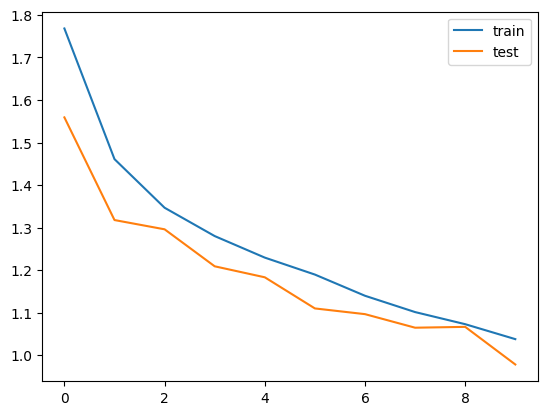

In [11]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label="train")
plt.plot(test_loss, label="test")
plt.legend()
plt.show()